In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import io

def read_horizons_csv(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()

    # 1. Find the markers and the header line
    # Usually, the column names are on the line before the '****************' that precedes $$SOE
    # For this specific file, the names are at line index 73
    soe_idx = next(i for i, line in enumerate(lines) if "$$SOE" in line)
    eoe_idx = next(i for i, line in enumerate(lines) if "$$EOE" in line)
    
    # Extract the header names (found just above the data)
    header_line = lines[soe_idx - 2].strip()
    columns = [col.strip() for col in header_line.split(',')]
    
    # Handle the "unnamed" flag columns (N, A, m, etc.)
    columns = [c if c else f"Flag_{i}" for i, c in enumerate(columns)]

    # 2. Extract only the data lines
    data_lines = lines[soe_idx + 1 : eoe_idx]
    
    # 3. Load into Pandas
    df = pd.read_csv(io.StringIO("".join(data_lines)), names=columns, header=None)
    return df

# Usage
df = read_horizons_csv('horizons_results_2001_FD58_csv.txt')
print(df.head())

print(df[['Date_________JDUT', 'r', 'delta']].head())

   Date_________JDUT Flag_1 Flag_2   R.A._(ICRF)   DEC__(ICRF)  dRA*cosD  \
0       2.461092e+06      N      m   07 27 11.98   +42 59 06.0  400.5659   
1       2.461092e+06      N      m   07 27 18.09   +42 57 21.8  399.1042   
2       2.461092e+06      A      m   07 27 24.17   +42 55 37.6  397.6905   
3       2.461092e+06      A      m   07 27 30.22   +42 53 53.4  396.3259   
4       2.461092e+06      A      m   07 27 36.25   +42 52 09.3  395.0111   

   d(DEC)/dt    a-mass   mag_ex   APmag    S-brt         r       rdot  \
0   -626.851     4.800    0.720  14.914     n.a.  1.039805  17.161903   
1   -626.627     4.486    0.673  14.916     n.a.  1.039874  17.160925   
2   -626.419     4.227    0.634  14.917     n.a.  1.039943  17.159947   
3   -626.226     4.012    0.602  14.918     n.a.  1.040012  17.158969   
4   -626.046     3.833    0.575  14.919     n.a.  1.040080  17.157991   

      delta     deldot    S-T-O  T-O-M  MN_Illu%  Flag_18  
0  0.073935  15.393727  44.8019  103.3    7.

In [3]:
dates = df["Date_________JDUT"].astype(float).to_numpy()

dates -= 2400000


In [41]:
night = '26_03_22/'

df_data = pd.read_csv(
            night + 'pipelineout_datasubset.dat', sep="\t", comment="#",
            names=["index", "Label", "J.D.-2400000", "rel_flux_T1", "rel_flux_err_T1",
                   "AIRMASS", "Source-Sky_T1", "Source_Error_T1"])

print(df_data['J.D.-2400000'].to_numpy())

dates_observ = df_data['J.D.-2400000'].to_numpy()

[61122.578859 61122.58109  61122.583314 61122.585542 61122.587761
 61122.589993 61122.59222  61122.59444  61122.596673 61122.5989
 61122.60115  61122.603372 61122.6056   61122.607827 61122.610053
 61122.612283 61122.61451  61122.616742 61122.618975 61122.621218
 61122.62344 ]


In [42]:
d_min = np.min(dates_observ)
d_max = np.max(dates_observ)

mask = (dates >= d_min - 0.5) & (dates <= d_max + 0.5)

new_r = np.interp(dates_observ, dates[mask], df["r"][mask])
new_delta = np.interp(dates_observ, dates[mask], df["delta"][mask])

new_phase_angle = np.interp(dates_observ, dates[mask], df["S-T-O"][mask])

In [43]:
def phi1(angle):
    return np.exp(-3.33*(np.tan(angle/2))**0.63)

def phi2(angle):
    return np.exp(1.87*(np.tan(angle/2))**1.22)


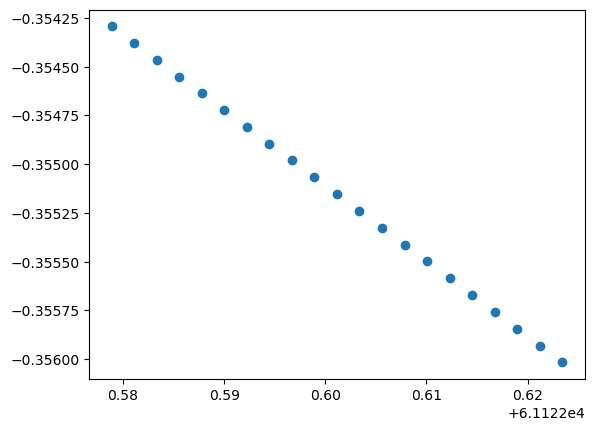

In [44]:
# see page 549-550 and "A three-parameter magnitude phase function for asteroids"

G = 0.15 # typical value when unknown

correction = -2.5*np.log10(new_r*new_delta) + 2.5*np.log10((1 - G)*phi1(new_phase_angle*np.pi/180) + G*phi2(new_phase_angle*np.pi/180))

plt.scatter(dates_observ, correction)
plt.show()

In [45]:
data = np.column_stack((dates_observ, correction))
df_out = pd.DataFrame({
    "Date_________JDUT": dates_observ,
    "mag_correction": correction
})

df_out.to_csv(night + "mag_correction.dat", sep="\t")
